# Data Loading

In [1]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.5 MB/s eta 0:00:00


**Insight**: Memuat pustaka yang diperlukan untuk analisis data, visualisasi, dan pemrosesan teks, termasuk Sastrawi untuk stemming dan stopwords dalam bahasa Indonesia.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import seaborn as sns
import os
import shutil
import re
import string
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [3]:
from google.colab import files
files.upload()  # upload kaggle.json kamu

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


**ingsight**: mengautentikasi akses ke Kaggle API, untuk mengunduh dataset atau mengakses fitur Kaggle langsung dari Colab.

In [4]:
# Download kaggle dataset and unzip the file
# !cp kaggle.json ~/.kaggle/

# !chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d muhammadghazimuharam/indonesiafalsenews
!unzip indonesiafalsenews.zip

Dataset URL: https://www.kaggle.com/datasets/muhammadghazimuharam/indonesiafalsenews
License(s): unknown
Archive:  indonesiafalsenews.zip
  inflating: Data_latih.csv          
  inflating: Data_uji.csv            


**Insight**: Download dataset berita hoax indonesia dari kaggle

In [5]:
# Baca file CSV
train_df = pd.read_csv('/content/Data_latih.csv')
test_df = pd.read_csv('/content/Data_uji.csv')

# Gabungkan train dan test
combined_df = pd.concat([train_df, test_df], ignore_index=True)

**Insight**: Menggabungkan dataset train dan test

In [6]:
# Lihat hasil
print(combined_df.shape)
combined_df.head()

(4701, 6)


,ID,label,tanggal,judul,narasi,nama file gambar
0,71,1.0,17-Aug-20,Pemakaian Masker Menyebabkan Penyakit Legionna...,A caller to a radio talk show recently shared ...,71.jpg
1,461,1.0,17-Jul-20,Instruksi Gubernur Jateng tentang penilangan ...,Yth.Seluruh Anggota Grup Sesuai Instruksi Gube...,461.png
2,495,1.0,13-Jul-20,Foto Jim Rohn: Jokowi adalah presiden terbaik ...,Jokowi adalah presiden terbaik dlm sejarah ban...,495.png
3,550,1.0,8-Jul-20,"ini bukan politik, tapi kenyataan Pak Jokowi b...","Maaf Mas2 dan Mbak2, ini bukan politik, tapi k...",550.png
4,681,1.0,24-Jun-20,Foto Kadrun kalo lihat foto ini panas dingin,Kadrun kalo lihat foto ini panas dingin . .,681.jpg


**Insight**: Menggabungkan dataset train dan test untuk analisis awal yang lebih menyeluruh.

# Exploratory Data Analysis

In [7]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4701 entries, 0 to 4700
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                4701 non-null   int64  
 1   label             4231 non-null   float64
 2   tanggal           4701 non-null   object 
 3   judul             4701 non-null   object 
 4   narasi            4701 non-null   object 
 5   nama file gambar  4701 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 220.5+ KB


**Insight**: Memeriksa keberadaan missing value dan menghapus baris dengan label yang hilang untuk memastikan kualitas data.

In [8]:
combined_df.describe()

,ID,label
count,4701.000000,4231.000000
mean,495773.615614,0.818955
std,288248.590648,0.385101
min,56.000000,0.000000
25%,243507.000000,1.000000
50%,498385.000000,1.000000
75%,746944.000000,1.000000
max,999860.000000,1.000000


### Melihat Missing Value

In [9]:
combined_df.isnull().sum()

,0
ID,0
label,470
tanggal,0
judul,0
narasi,0
nama file gambar,0


In [10]:
combined_df[combined_df['label'].isnull()]

,ID,label,tanggal,judul,narasi,nama file gambar
4231,238057,NaN,13-Jul-20,Narasi Tito Karnavian Berideologi Komunis Kare...,TITO KARNIVAN ITU BERIDIOLOGI KOMUNIS DIA BISA...,238057.jpg
4232,238158,NaN,6-Jul-20,Anies: Seberat beratnya Pekerjaan Akan terasa ...,Seberat beratnya Pekerjaan Akan terasa ringan ...,238158.jpg
4233,238865,NaN,22-Apr-20,Hindu di india Melemparkan Patung Buatan Merek...,Hindu di india melemparkan patung buatan merek...,238865.jpg
4234,248298,NaN,22-Oct-19,RSCM Praktekkan Penyedotan Plug Vena/Saluran ...,Mulai Hari ini di RSCM mulai diPraktekkan Peny...,248298.jpg
4235,255176,NaN,1-May-20,Permohonan Kelonggaran Angsuran ke OJK,"Untuk sekedar info, Bagi anda yg punya ansuran...",255176.jpg
...,...,...,...,...,...,...
4696,206021,NaN,1-May-20,"Dijemput oleh Tim Medis, Kakak Beradik Usia 8 ...","DiTangerang, dua bersaudara kakak beradik usia...",206021.jpg
4697,219874,NaN,2-Oct-17,": Pertanda Alam, Kera Putih Mulai Turun Dari G...","Pertanda Alam, Kera Putih Mulai Turun Dari Gun...",219874.jpg
4698,222802,NaN,22-Mar-20,Pasar Wameo dan Karya Nugraha di Tutup selama ...,Assalamu Alaikum …\n \n Info dari pedagang pa...,222802.jpg
4699,226020,NaN,25-Sep-18,Klarifikasi KPK Terkait Foto Setya Novanto Tan...,Secara tidak sengaja sekitar pukul 06.00 WIB d...,226020.jpg


In [11]:
combined_df = combined_df.dropna(subset=['label'])

In [12]:
jumlah_hoax = combined_df[combined_df['label'] == 1].shape[0]
jumlah_benar = combined_df[combined_df['label'] == 0].shape[0]

print("Jumlah Berita Hoax (label 1):", jumlah_hoax)
print("Jumlah Berita Benar (label 0):", jumlah_benar)

Jumlah Berita Hoax (label 1): 3465
Jumlah Berita Benar (label 0): 766


### Distribusi Label

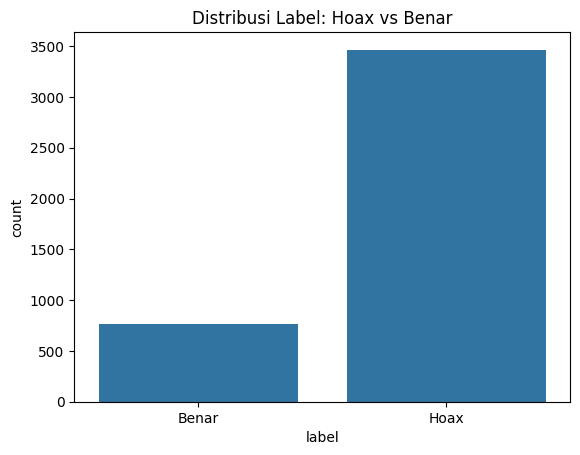

In [13]:
sns.countplot(x='label', data=combined_df)
plt.title('Distribusi Label: Hoax vs Benar')
plt.xticks([0, 1], ['Benar', 'Hoax'])
plt.show()

**Insight**: Memvisualisasikan distribusi label untuk melihat apakah dataset seimbang antara berita hoax dan benar.

### Panjang Teks (judul + narasi)

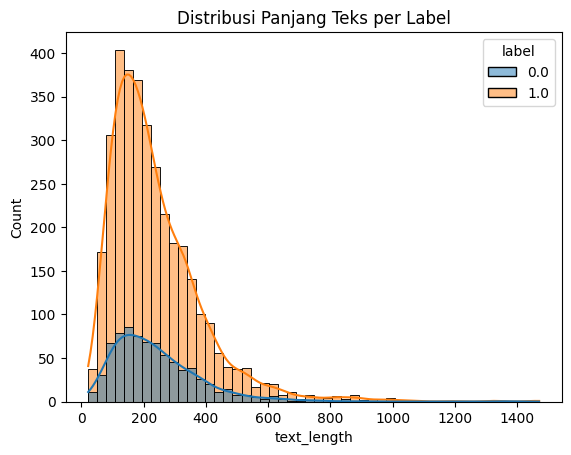

In [14]:
combined_df['text_length'] = combined_df['judul'].str.len() + combined_df['narasi'].str.len()
sns.histplot(data=combined_df, x='text_length', hue='label', bins=50, kde=True)
plt.title('Distribusi Panjang Teks per Label')
plt.show()

**Insight**: Menganalisis panjang teks untuk melihat apakah ada pola tertentu antara panjang teks dan label (hoax/benar).

# Data Preprocessing

In [15]:
indofakenews_df = combined_df
indofakenews_df.shape

(4231, 7)

In [16]:
indofakenews_df['teks'] = indofakenews_df['judul'] + ' ' + indofakenews_df['narasi']

In [17]:
indofakenews_df = indofakenews_df[['teks', 'label']]

**Insight**: Menggabungkan kolom judul dan narasi menjadi satu kolom teks untuk mempermudah pemrosesan lebih lanjut.

In [18]:
!pip install tqdm
from tqdm import tqdm
tqdm.pandas()

In [19]:
from functools import lru_cache

# Stemmer & stopwords dari sebelumnya
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())  # pakai set agar lookup cepat

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

@lru_cache(maxsize=10000)
def cached_stem(word):
    return stemmer.stem(word)

def preprocess_fast(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [cached_stem(w) for w in words if w not in stopwords]
    return ' '.join(words)


**Insight**:
* @lru_cache mempercepat stemming dengan menyimpan hasil sebelumnya.

* tqdm bantu pantau progres (terutama jika butuh waktu beberapa menit).

* set(stopwords) jauh lebih cepat saat cek keanggotaan dibanding list biasa.

In [20]:
indofakenews_df['clean_text'] = indofakenews_df['teks'].progress_apply(preprocess_fast)

100%|██████████| 4231/4231 [21:30<00:00,  3.28it/s]
<ipython-input-20-5aaab1712feb>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  indofakenews_df['clean_text'] = indofakenews_df['teks'].progress_apply(preprocess_fast)


# Split Data

In [21]:
from sklearn.model_selection import train_test_split

# Split data menjadi data latih (train) dan data uji (test)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    indofakenews_df['clean_text'], indofakenews_df['label'],
    test_size=0.2, stratify=indofakenews_df['label'], random_state=42)

# Lihat jumlah data
print("Jumlah data latih:", len(X_train_text))
print("Jumlah data uji:", len(X_test_text))

Jumlah data latih: 3384
Jumlah data uji: 847


**Insight**: Membagi data menjadi set pelatihan dan pengujian dengan rasio 80:20, menggunakan stratifikasi untuk menjaga distribusi label.

# Ekstraksi fitur

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi vectorizer dengan ngram_range=(1, 2) untuk unigram dan bigram
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))

# Fit dan transform data latih, transform data uji
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

**Insight**: Menggunakan TF-IDF untuk mengubah teks menjadi fitur numerik, dengan unigram dan bigram untuk menangkap konteks kata.

### Tangani data tidak seimbang dengan SMOTE

In [33]:
from imblearn.over_sampling import SMOTE

# Terapkan SMOTE pada data latih (X_train, y_train)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

**Insight**: Menggunakan SMOTE untuk menyeimbangkan data pelatihan, agar model tidak bias terhadap kelas mayoritas.

In [34]:
print("Distribusi kelas setelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Distribusi kelas setelah SMOTE:
label
0.0    2771
1.0    2771
Name: count, dtype: int64


# Train Model

### Support Vector Machine (SVM)

Akurasi: 0.8417945690672963
Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.21      0.32       153
         1.0       0.85      0.98      0.91       694

    accuracy                           0.84       847
   macro avg       0.78      0.60      0.62       847
weighted avg       0.82      0.84      0.80       847



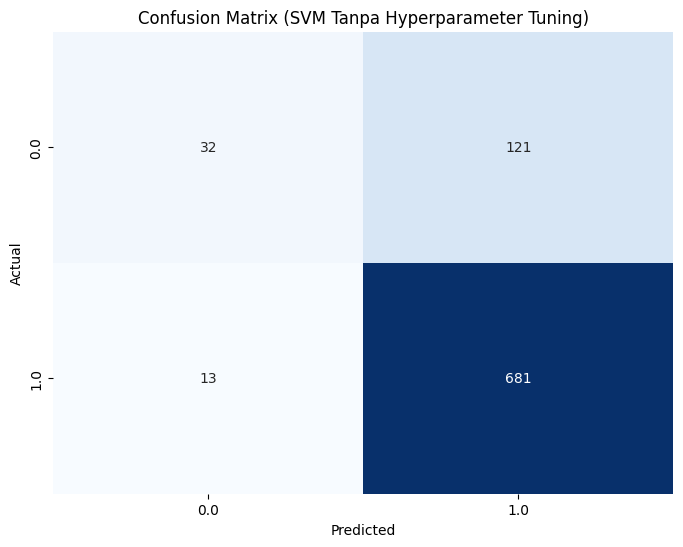

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Inisialisasi dan latih model SVM pada data latih yang sudah diperbaiki dengan SMOTE
svm_model = SVC(random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)

# Evaluasi model dengan data uji
y_pred = svm_model.predict(X_test_tfidf)

# Tampilkan hasil evaluasi
print(f"Akurasi: {accuracy_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = np.unique(y_test)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (SVM Tanpa Hyperparameter Tuning)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Insight**: Melatih model SVM pada data yang telah diseimbangkan, lalu mengevaluasi performa dengan metrik akurasi, laporan klasifikasi, dan Confusion Matrix.

Akurasi Random Forest (Tanpa Hyperparameter Tuning): 0.8370720188902007
Classification Report:
              precision    recall  f1-score   support

         0.0       0.56      0.43      0.49       153
         1.0       0.88      0.93      0.90       694

    accuracy                           0.84       847
   macro avg       0.72      0.68      0.70       847
weighted avg       0.82      0.84      0.83       847



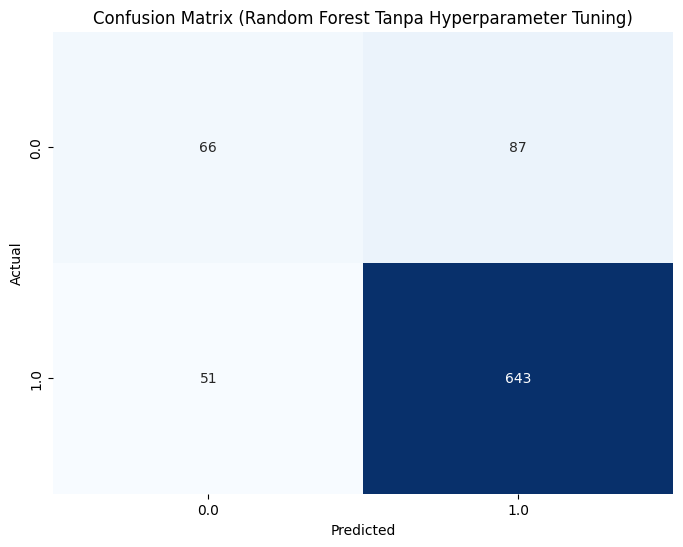

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Inisialisasi model Random Forest dengan parameter default
rf_model = RandomForestClassifier(random_state=42)

# Latih model pada data latih yang sudah diperbaiki dengan SMOTE
rf_model.fit(X_train_resampled, y_train_resampled)

# Prediksi pada data uji
y_pred_rf = rf_model.predict(X_test_tfidf)

# Tampilkan hasil evaluasi
print(f"Akurasi Random Forest (Tanpa Hyperparameter Tuning): {accuracy_score(y_test, y_pred_rf)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
labels = np.unique(y_test)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Random Forest Tanpa Hyperparameter Tuning)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Insight**: Melatih model Random Forest sebagai alternatif, lalu membandingkan performanya dengan SVM menggunakan metrik evaluasi yang sama.

# Evaluasi

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
# Inisialisasi model Random Forest
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Definisikan grid parameter untuk RandomizedSearch
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1)

# Fit model dengan cross-validation
random_search.fit(X_train_resampled, y_train_resampled)

# Output hasil terbaik
print("Best Parameters (Randomized Search):", random_search.best_params_)
print("Best Cross-validation Score:", random_search.best_score_)

# Evaluasi model terbaik
y_pred_random = random_search.best_estimator_.predict(X_test_tfidf)
print("Akurasi dengan RandomizedSearch: ", accuracy_score(y_test, y_pred_random))

# Tampilkan hasil evaluasi
print(f"Akurasi dengan RandomizedSearch: {accuracy_score(y_test, y_pred_random)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_random))


Best Parameters (Randomized Search): {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best Cross-validation Score: 0.9142988284238248
Akurasi dengan RandomizedSearch:  0.8394332939787486
Akurasi dengan RandomizedSearch: 0.8394332939787486
Classification Report:
              precision    recall  f1-score   support

         0.0       0.58      0.42      0.48       153
         1.0       0.88      0.93      0.90       694

    accuracy                           0.84       847
   macro avg       0.73      0.68      0.69       847
weighted avg       0.82      0.84      0.83       847



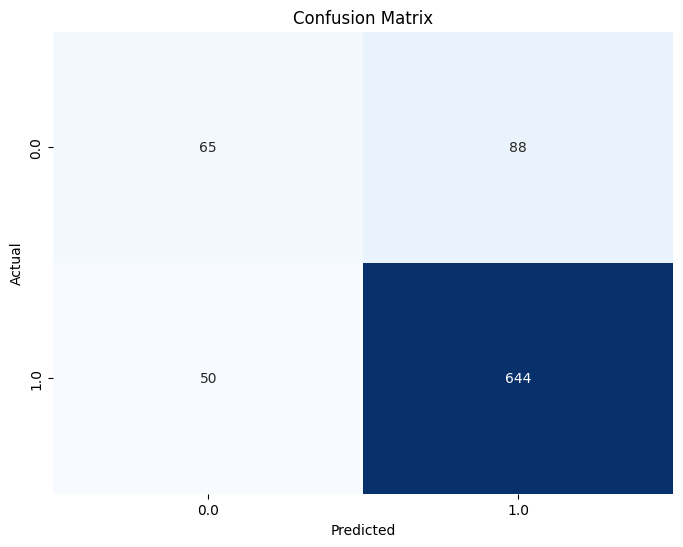

In [37]:
# Asumsi y_test dan y_pred_random sudah ada dari kode sebelumnya
# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred_random)

# Mendapatkan label kelas (misalnya, jika y_test berupa kategori biner atau multiclass)
labels = np.unique(y_test)

# Membuat DataFrame untuk visualisasi
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Visualisasi Confusion Matrix dengan heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Insight**: Mengoptimalkan model Random Forest dengan RandomizedSearchCV untuk menemukan hyperparameter terbaik, lalu mengevaluasi performanya.

In [38]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Inisialisasi model SVM
svm_model = SVC(random_state=42)

# Definisikan grid parameter untuk RandomizedSearch
param_dist = {
    'C': [0.1, 1, 10, 100],  # Nilai C untuk regularisasi
    'kernel': ['linear', 'rbf', 'poly'],  # Jenis kernel
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Nilai gamma untuk kernel rbf/poly
    'degree': [2, 3, 4],  # Derajat polinomial (hanya berlaku untuk kernel 'poly')
}

# Setup RandomizedSearchCV
random_search_svm = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=param_dist,
    n_iter=10,  # Jumlah kombinasi yang akan dicoba
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Metrik evaluasi
    n_jobs=-1,  # Gunakan semua CPU untuk mempercepat
    random_state=42
)

# Fit model dengan cross-validation pada data yang sudah diperbaiki dengan SMOTE
random_search_svm.fit(X_train_resampled, y_train_resampled)

# Output hasil terbaik
print("Best Parameters (Randomized Search untuk SVM):", random_search_svm.best_params_)
print("Best Cross-validation Score:", random_search_svm.best_score_)

# Evaluasi model terbaik pada data uji
y_pred_svm = random_search_svm.best_estimator_.predict(X_test_tfidf)

# Tampilkan hasil evaluasi
print(f"Akurasi dengan RandomizedSearch: {accuracy_score(y_test, y_pred_svm)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))


Best Parameters (Randomized Search untuk SVM): {'kernel': 'rbf', 'gamma': 'scale', 'degree': 3, 'C': 1}
Best Cross-validation Score: 0.9264109208217637
Akurasi dengan RandomizedSearch: 0.8417945690672963
Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.21      0.32       153
         1.0       0.85      0.98      0.91       694

    accuracy                           0.84       847
   macro avg       0.78      0.60      0.62       847
weighted avg       0.82      0.84      0.80       847



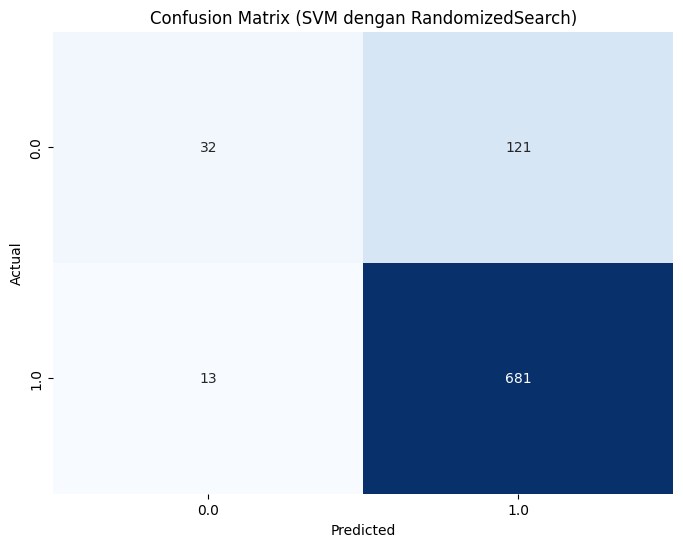

In [39]:
# Visualisasi Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)
labels = np.unique(y_test)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (SVM dengan RandomizedSearch)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Insight**: Mengoptimalkan model SVM dengan RandomizedSearchCV untuk meningkatkan performa, lalu mengevaluasi hasilnya dengan metrik yang sama.